In [104]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from scipy import stats
import utils
import seaborn as sns
import pingouin as pg
import matplotlib.cm as cm

import statsmodels.stats.power as smp
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
from tqdm import tqdm


from natsort import index_natsorted

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.family'] = 'Calibri'

path_figs = "./Figs/"

fingers = ['1', '2', '3', '4', '5']

iti = 1000 # msecs for inter-trial interval
planTime = 2000 # msecs for precue time
feedbackTime = 2000 # msecs for feedback time


total_sub_num = 20
num_sessions = 2
num_blocks_per_session = 12
num_trials_per_block = 30

sub_nums = [1,2]
# sub_nums = [2]

utils.set_figure_style("1col")
sns.color_palette('colorblind')


[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [105]:
subjs = pd.read_csv(utils.path_misc+'subjs.csv', sep = '\t')

subjs = subjs[subjs['subNum'].isin(sub_nums)].reset_index(drop=True)


In [106]:
subjs.columns

Index(['subNum', 'BN', 'TN', 'trial_num_within_chord', 'TotalTrialNum',
       'targetForce1', 'targetForce2', 'targetForce3', 'targetForce4',
       'targetForce5', 'endForce1', 'endForce2', 'endForce3', 'endForce4',
       'endForce5', 'isTargetVisible', 'endForcePurturbed1',
       'endForcePurturbed2', 'endForcePurturbed3', 'endForcePurturbed4',
       'endForcePurturbed5', 'purturbation1', 'purturbation2', 'forceGain',
       'trialCorr', 'trialErrorType', 'num_targets', 'chord', 'day',
       'block_type'],
      dtype='str')

In [107]:
subjs_correct = utils.remove_error_trials(subjs).copy()

In [108]:
subjs_correct.columns

Index(['subNum', 'BN', 'TN', 'trial_num_within_chord', 'TotalTrialNum',
       'targetForce1', 'targetForce2', 'targetForce3', 'targetForce4',
       'targetForce5', 'endForce1', 'endForce2', 'endForce3', 'endForce4',
       'endForce5', 'isTargetVisible', 'endForcePurturbed1',
       'endForcePurturbed2', 'endForcePurturbed3', 'endForcePurturbed4',
       'endForcePurturbed5', 'purturbation1', 'purturbation2', 'forceGain',
       'trialCorr', 'trialErrorType', 'num_targets', 'chord', 'day',
       'block_type'],
      dtype='str')

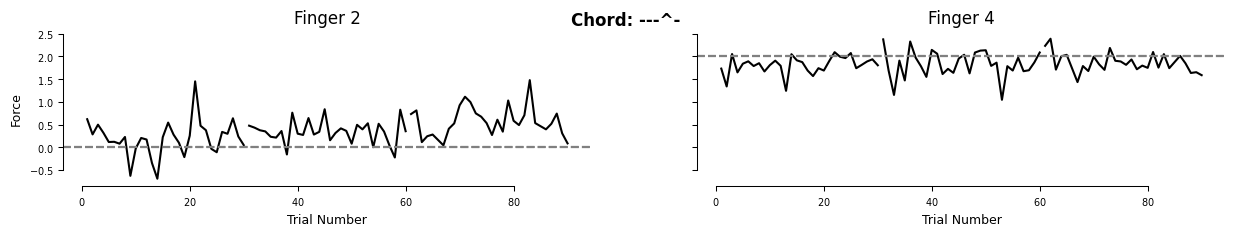

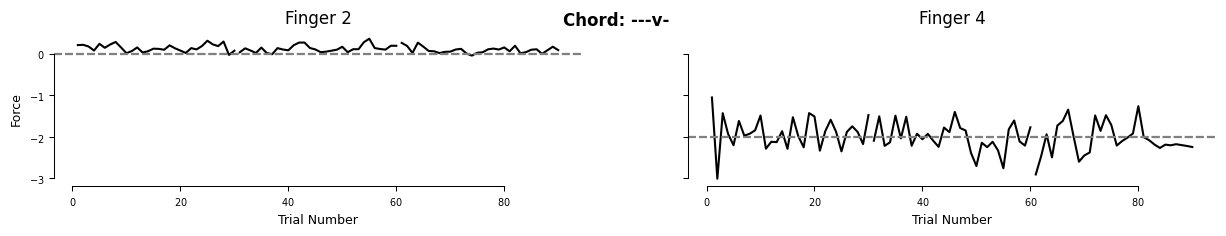

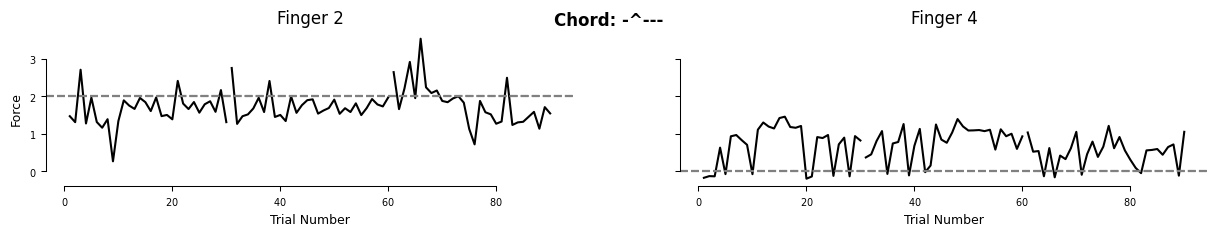

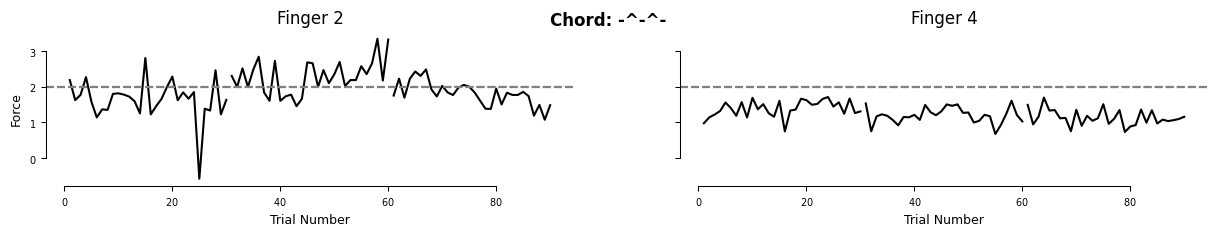

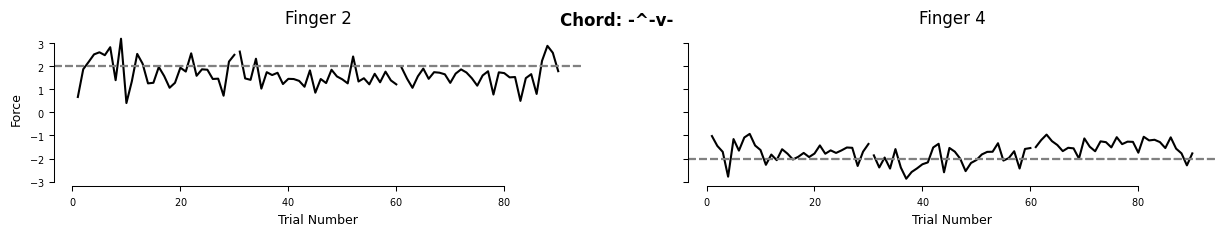

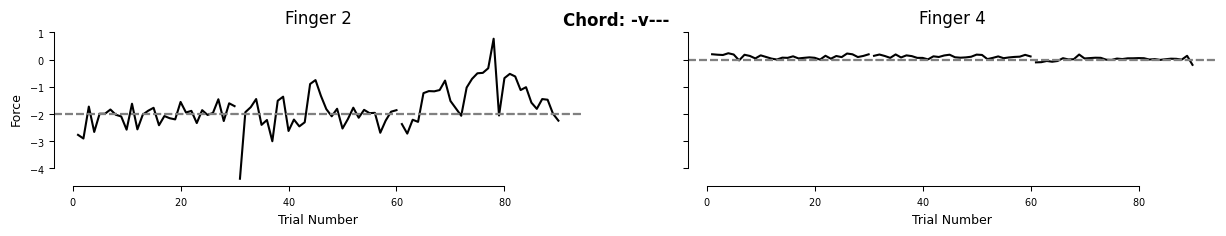

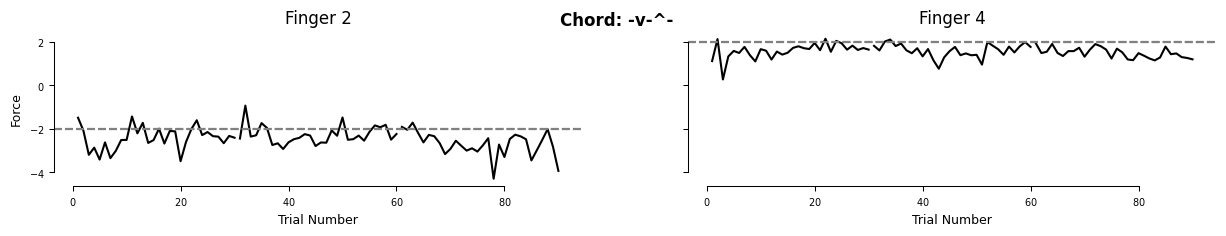

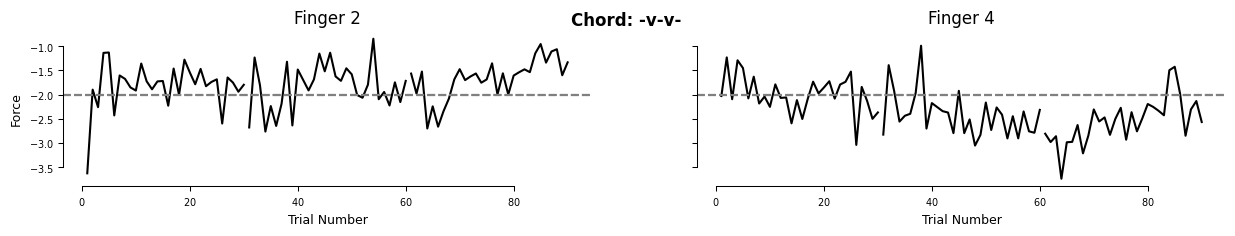

In [109]:
for chord, chord_data in subjs_correct.groupby('chord'):
    fig, axs = plt.subplots(1, 2, figsize=(15, 2), sharey=True)

    for block_type, block_type_data in chord_data.groupby('block_type'):
        for idx, finger in enumerate([2,4]):
            # sns.lineplot(data = block_type_data, x = 'trial_num_within_chord', y = f'endForce{finger}', 
            # ax = axs[idx], color = 'black', errorbar = 'se')
            sns.lineplot(data = block_type_data, x = 'trial_num_within_chord', y = f'endForce{finger}', 
            ax = axs[idx], color = 'black', errorbar = None)
            # sns.lineplot(data = block_type_data, x = 'trial_num_within_chord', y = f'endForcePurturbed{finger}', 
            # ax = axs[idx], color = 'gray', linestyle = '--')
            if block_type == 'purturbed':
                # print(block_type_data[f'purturbation{idx+1}'])
                pass
            axs[idx].axhline(block_type_data[f'targetForce{finger}'].iloc[0], color = 'gray', linestyle = '--')
            axs[idx].set_xlabel('Trial Number')
            axs[idx].set_ylabel('Force')
            axs[idx].set_title(f'Finger {finger}')
    
    sns.despine(trim = True)
            
    fig.suptitle(f'Chord: {chord}')
    plt.show()


## Parameter estimation methods

Two approaches are used in this notebook to estimate the state-space learning model parameters. The schematic below summarizes how each pipeline processes the data and what it outputs.

- **Method A (covariance shortcut):** closed-form estimate of the **B** matrix per subject × chord — suitable for group-level statistics across participants.
- **Method B (Nelder–Mead MLE):** iterative fit of **A** (retention) and **B** (learning) on trial data averaged across subjects — one parameter set per chord.

Saved: ./Figs/estimation_methods_schematic.png
Saved: ./Figs/estimation_methods_schematic.pdf


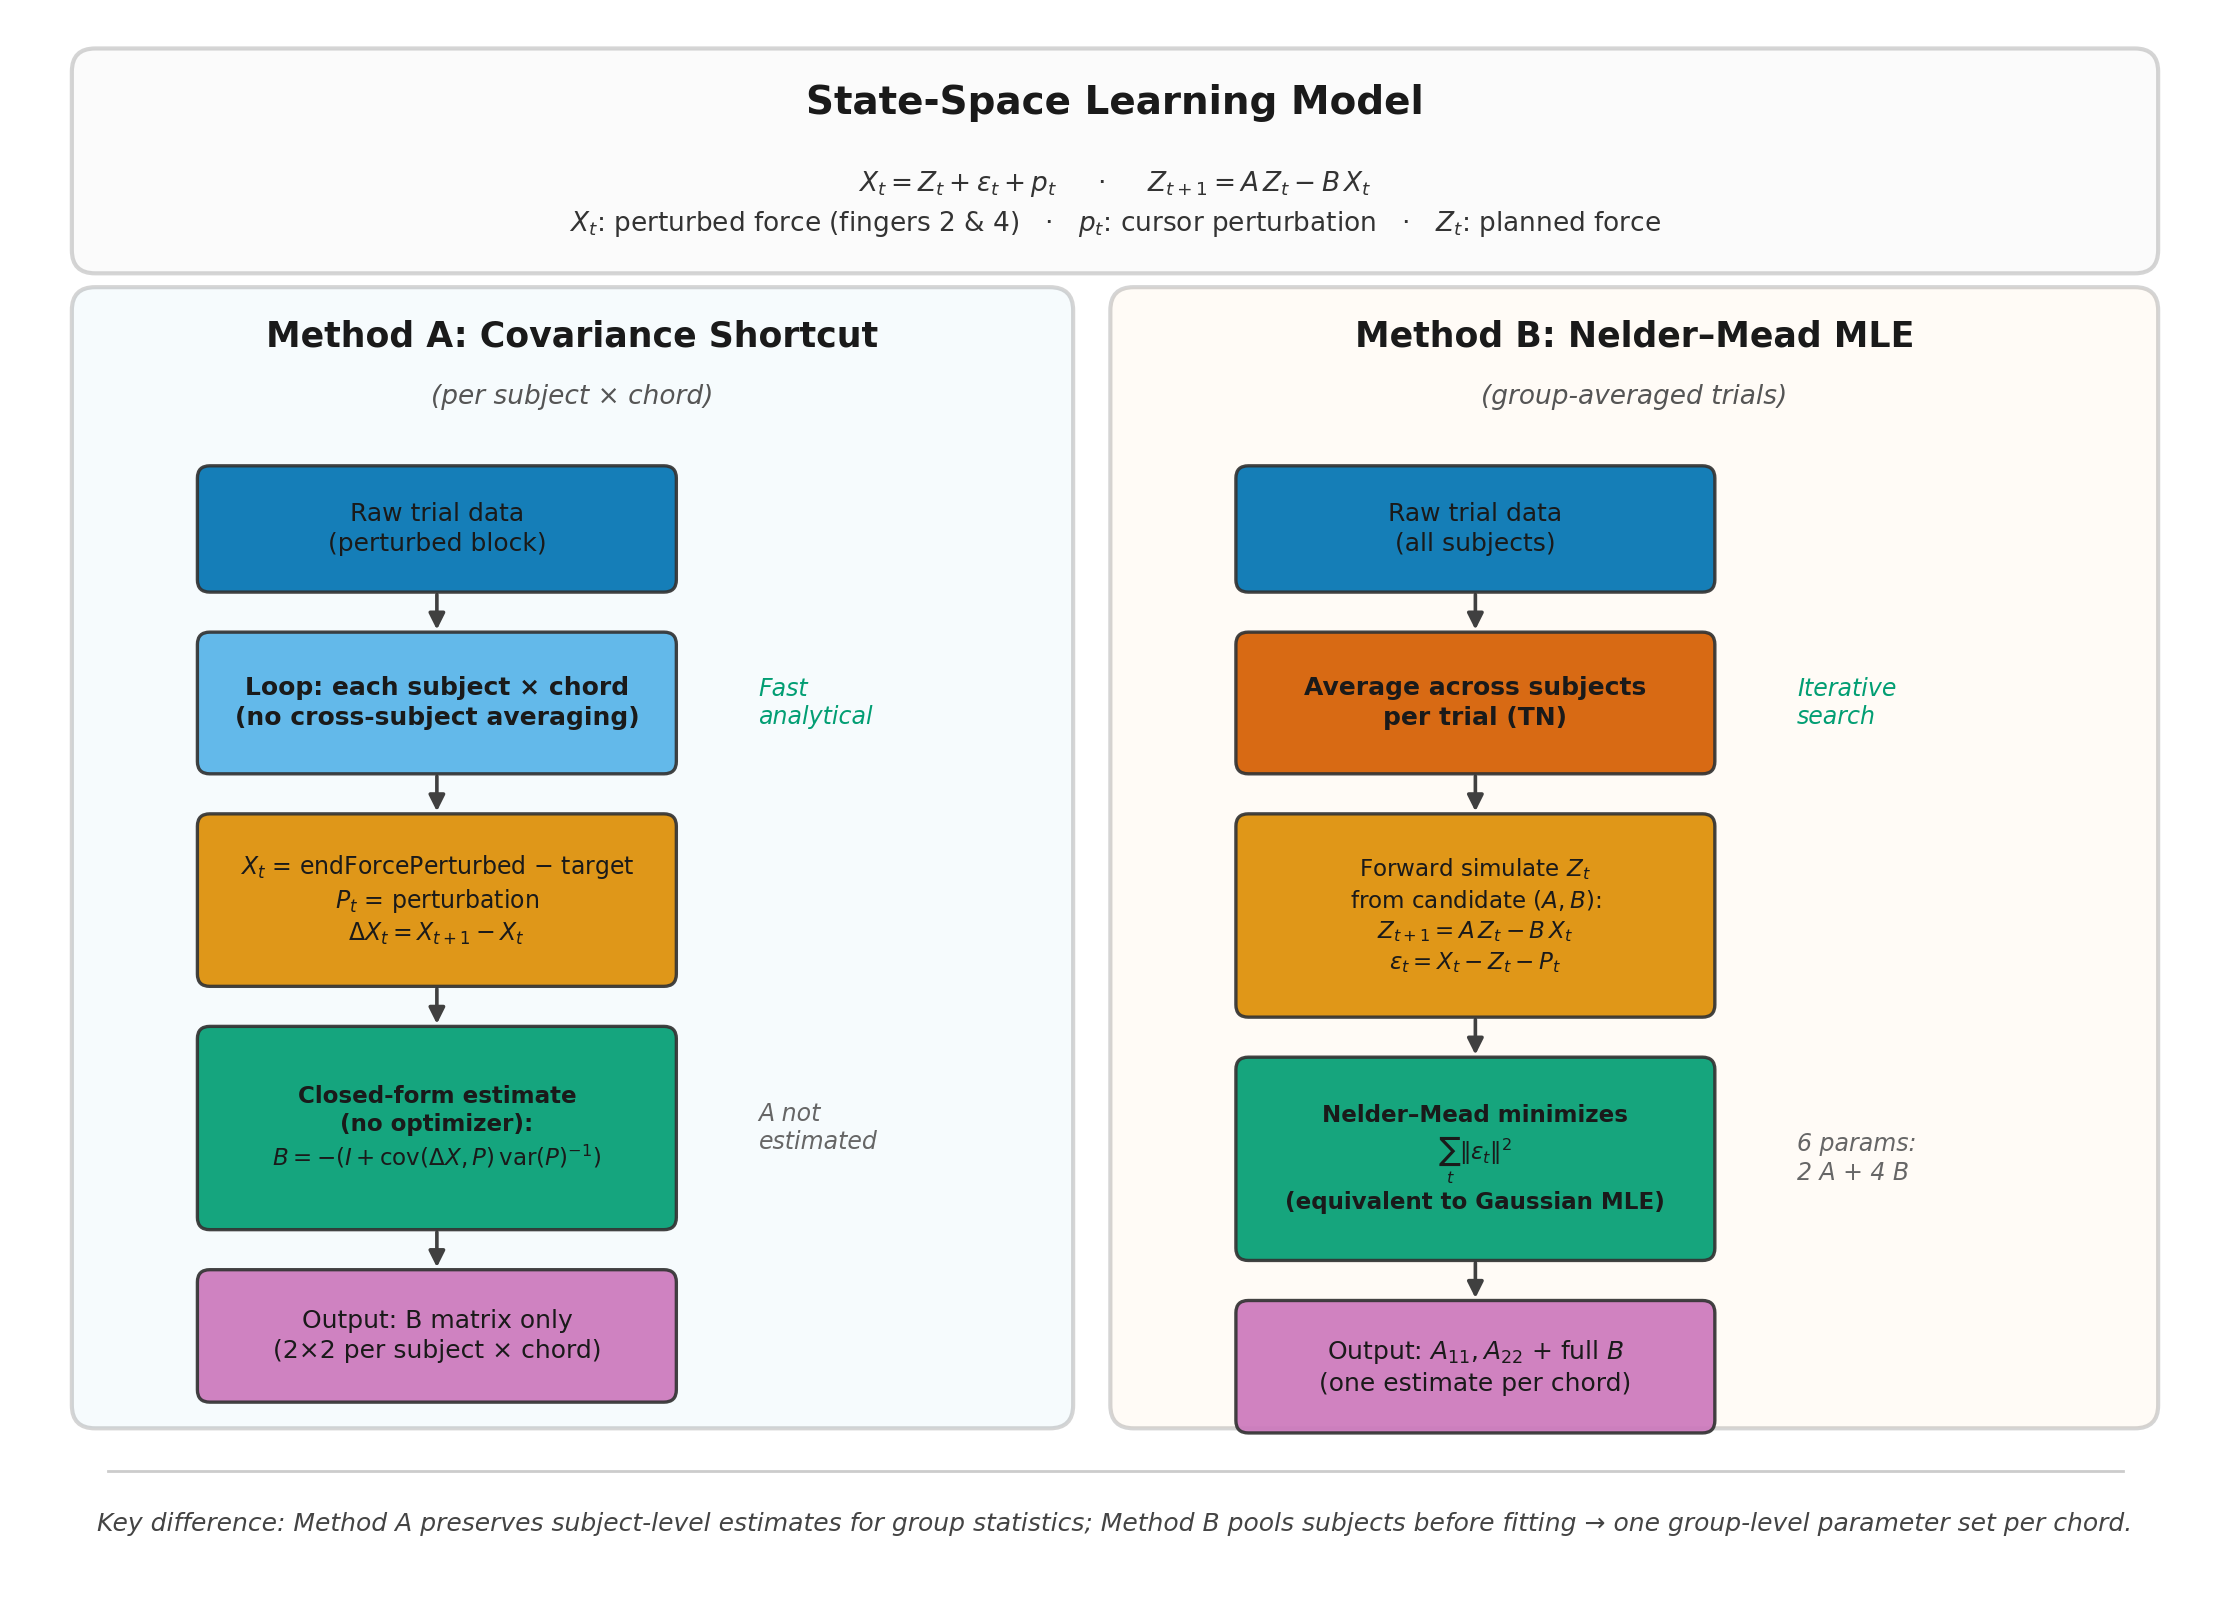

In [110]:
# Generate presentation schematic (also saved to ./Figs/)
from IPython.display import Image, display
from make_estimation_schematic import make_schematic

make_schematic(
    './Figs/estimation_methods_schematic.png',
    './Figs/estimation_methods_schematic.pdf',
)
display(Image(filename='./Figs/estimation_methods_schematic.png', width=1100))

In [111]:
# assuming the following model:

# assumed here the target force is 0 (target is subtracted from following Xs and Zs)
# X_t = Z_t + \epsilon_t + p_t (the perturbation)
# where Z_t is the planned force, \epsilon_t is the execution noise, and p_t is the perturbation applied on trial t
# Z_t+1 = A * (Z_t) + B * (X_t)

# ==> X_t+1 - X_t = Z_t+1 - Z_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t
# ==> X_t+1 - X_t = A * Z_t + B * X_t - Z_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t
# ==> X_t+1 - X_t = (A - 1) * Z_t + B * X_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t
# ==> X_t+1 - X_t = (A - 1) * Z_t + B * (Z_t + \epsilon_t + p_t) + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t
# ==> X_t+1 - X_t = (A - 1) * Z_t + B * Z_t + B * \epsilon_t + B * p_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t
# ==> X_t+1 - X_t = (A - 1) * Z_t + (B - 1) * \epsilon_t + (B - 1) * p_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t

# If we assume that the execution noise \epsilon_t is zero-mean and uncorrelated across trials, and that the perturbation p_t is also zero-mean and uncorrelated across trials,
# then we can estimate the learning rate B by regressing the trial-to-trial changes in force (X_t+1 - X_t) on to the p_t.

# cov(X_t+1 - X_t, p_t) = cov((A - 1) * Z_t + (B - 1) * \epsilon_t + (B - 1) * p_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t, p_t)
# cov(X_t+1 - X_t, p_t) = (B - 1) * var(p_t)
# B = 1 + cov(X_t+1 - X_t, p_t) / var(p_t)

# p_t is external: N(0, std = 0.5N) independently applied on each finger, and uncorrelated across trials
# X_t is the endForcePurturbed, which is the sum of the planned force Z_t, the execution noise \epsilon_t, and the perturbation p_t


betas = []

for chord, chord_data in subjs_correct.groupby('chord'):
    for block_type, block_type_data in chord_data.groupby('block_type'):
        if block_type == 'purturbed':
            print(f'Block type: {block_type}, Chord: {chord}')
            grouped_data = block_type_data.copy()
            grouped_data = grouped_data.groupby(['TN']).agg({
                'endForcePurturbed2': 'mean',
                'endForcePurturbed4': 'mean',
                'purturbation1': 'mean',
                'purturbation2': 'mean',
            })
            grouped_data = grouped_data.reset_index()
            # print(grouped_data)
            X = grouped_data[[f'endForcePurturbed{i}' for i in [2, 4]]].values
            P = grouped_data[[f'purturbation{i}' for i in [1, 2]]].values
            print(X.shape, P.shape)
            delta_X = X[1:] - X[:-1] # shape (num_trials-1, 2)
            P_t = P[:-1] # shape (num_trials-1, 2)
            cov_X_P = np.cov(delta_X.T, P_t.T)
            cov_X_P = cov_X_P[:2, 2:] # shape (2, 2)
            var_P = np.cov(P_t.T) # shape (2, 2)

            matrix_mult = cov_X_P @ np.linalg.pinv(var_P)
            # matrix_mult = cov_X_P @ np.linalg.inv(var_P)
            B = -1* (np.eye(2) + matrix_mult)
            # print(B)

            for idx, finger in enumerate([2,4]):
                if block_type_data[f'targetForce{finger}'].iloc[0] == 0:
                    B[:, idx] = np.nan
            print(B)

            betas.append({
                'chord': chord,
                'num_fingers': block_type_data['num_targets'].iloc[0],
                'B11': np.round(B[0, 0], 2),
                'B12': np.round(B[0, 1], 2),
                'B21': np.round(B[1, 0], 2),
                'B22': np.round(B[1, 1], 2),
            })

betas = pd.DataFrame(betas)





Block type: purturbed, Chord: ---^-
(30, 2) (30, 2)
[[        nan -0.18182009]
 [        nan -0.11584533]]
Block type: purturbed, Chord: ---v-
(30, 2) (30, 2)
[[        nan -0.04249652]
 [        nan  0.70105781]]
Block type: purturbed, Chord: -^---
(30, 2) (30, 2)
[[0.31663752        nan]
 [0.39774115        nan]]
Block type: purturbed, Chord: -^-^-
(30, 2) (30, 2)
[[ 0.24394599 -0.00777599]
 [ 0.01872989  0.1453937 ]]
Block type: purturbed, Chord: -^-v-
(30, 2) (30, 2)
[[ 0.38224775  0.09005978]
 [-0.12872394  0.12777546]]
Block type: purturbed, Chord: -v---
(30, 2) (30, 2)
[[ 0.12700606         nan]
 [-0.03957115         nan]]
Block type: purturbed, Chord: -v-^-
(30, 2) (30, 2)
[[ 0.37009933  0.27896032]
 [-0.28122977  0.00832718]]
Block type: purturbed, Chord: -v-v-
(29, 2) (29, 2)
[[-0.29654863  0.18028835]
 [-0.80696355  0.19119465]]


In [112]:
betas

,chord,num_fingers,B11,B12,B21,B22
0,---^-,1,NaN,-0.18,NaN,-0.12
1,---v-,1,NaN,-0.04,NaN,0.70
2,-^---,1,0.32,NaN,0.40,NaN
3,-^-^-,2,0.24,-0.01,0.02,0.15
4,-^-v-,2,0.38,0.09,-0.13,0.13
5,-v---,1,0.13,NaN,-0.04,NaN
6,-v-^-,2,0.37,0.28,-0.28,0.01
7,-v-v-,2,-0.30,0.18,-0.81,0.19


In [113]:
betas['mean_B_diag'] = betas[['B11', 'B22']].mean(axis = 1)
betas['mean_B_off_diag'] = betas[['B12', 'B21']].mean(axis = 1)

In [114]:
betas

,chord,num_fingers,B11,B12,B21,B22,mean_B_diag,mean_B_off_diag
0,---^-,1,NaN,-0.18,NaN,-0.12,-0.120,-0.180
1,---v-,1,NaN,-0.04,NaN,0.70,0.700,-0.040
2,-^---,1,0.32,NaN,0.40,NaN,0.320,0.400
3,-^-^-,2,0.24,-0.01,0.02,0.15,0.195,0.005
4,-^-v-,2,0.38,0.09,-0.13,0.13,0.255,-0.020
5,-v---,1,0.13,NaN,-0.04,NaN,0.130,-0.040
6,-v-^-,2,0.37,0.28,-0.28,0.01,0.190,0.000
7,-v-v-,2,-0.30,0.18,-0.81,0.19,-0.055,-0.315


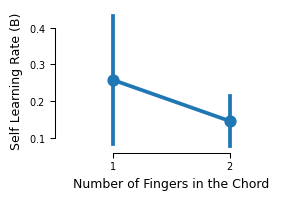

In [115]:
sns.pointplot(data = betas, x = 'num_fingers', y = 'mean_B_diag', errorbar='se')
plt.xlabel('Number of Fingers in the Chord')
plt.ylabel('Self Learning Rate (B)')
sns.despine(trim = True)

In [116]:
def determine_two_finger_chord_type(row):
    if row['num_fingers'] == 1:
        return 'one_finger'
    else:   
        fingers = row['chord'].split('-')
        if fingers[1] == fingers[2]:
            return 'symmetric'
        else:
            return 'asymmetric'


In [117]:
betas['chord_type'] = betas.apply(determine_two_finger_chord_type, axis = 1)
betas

,chord,num_fingers,B11,B12,B21,B22,mean_B_diag,mean_B_off_diag,chord_type
0,---^-,1,NaN,-0.18,NaN,-0.12,-0.120,-0.180,one_finger
1,---v-,1,NaN,-0.04,NaN,0.70,0.700,-0.040,one_finger
2,-^---,1,0.32,NaN,0.40,NaN,0.320,0.400,one_finger
3,-^-^-,2,0.24,-0.01,0.02,0.15,0.195,0.005,symmetric
4,-^-v-,2,0.38,0.09,-0.13,0.13,0.255,-0.020,asymmetric
5,-v---,1,0.13,NaN,-0.04,NaN,0.130,-0.040,one_finger
6,-v-^-,2,0.37,0.28,-0.28,0.01,0.190,0.000,asymmetric
7,-v-v-,2,-0.30,0.18,-0.81,0.19,-0.055,-0.315,symmetric


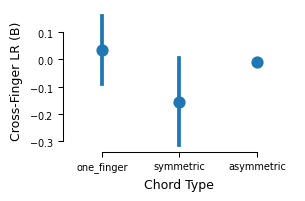

In [118]:
sns.pointplot(data = betas, x = 'chord_type', y = 'mean_B_off_diag', errorbar='se',
linestyle = ' ')
plt.xlabel('Chord Type')
plt.ylabel('Cross-Finger LR (B)')
sns.despine(trim = True)


In [119]:
# assuming the following model:

# assumed here the target force is 0 (target is subtracted from following Xs and Zs)
# X_t = Z_t + \epsilon_t + p_t (the perturbation)
# where Z_t is the planned force, \epsilon_t is the execution noise, and p_t is the perturbation applied on trial t
# Z_t+1 = A * (Z_t) + B * (X_t)

# ==> X_t+1 - X_t = Z_t+1 - Z_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t
# ==> X_t+1 - X_t = A * Z_t + B * X_t - Z_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t
# ==> X_t+1 - X_t = (A - 1) * Z_t + B * X_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t
# ==> X_t+1 - X_t = (A - 1) * Z_t + B * (Z_t + \epsilon_t + p_t) + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t
# ==> X_t+1 - X_t = (A - 1) * Z_t + B * Z_t + B * \epsilon_t + B * p_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t
# ==> X_t+1 - X_t = (A - 1) * Z_t + (B - 1) * \epsilon_t + (B - 1) * p_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t

# If we assume that the execution noise \epsilon_t is zero-mean and uncorrelated across trials, and that the perturbation p_t is also zero-mean and uncorrelated across trials,
# then we can estimate the learning rate B by regressing the trial-to-trial changes in force (X_t+1 - X_t) on to the p_t.

# cov(X_t+1 - X_t, p_t) = cov((A - 1) * Z_t + (B - 1) * \epsilon_t + (B - 1) * p_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t, p_t)
# cov(X_t+1 - X_t, p_t) = (B - 1) * var(p_t)
# B = 1 + cov(X_t+1 - X_t, p_t) / var(p_t)

# p_t is external: N(0, std = 0.5N) independently applied on each finger, and uncorrelated across trials
# X_t is the endForcePurturbed, which is the sum of the planned force Z_t, the execution noise \epsilon_t, and the perturbation p_t


betas = []

for subj, subj_data in subjs_correct.groupby('subNum'):
    for chord, chord_data in subj_data.groupby('chord'):
        for block_type, block_type_data in chord_data.groupby('block_type'):
            if block_type == 'purturbed':
                print(f'Block type: {block_type}, Chord: {chord}')
                grouped_data = block_type_data.copy()
                grouped_data = grouped_data.groupby(['TN']).agg({
                    'endForcePurturbed2': 'mean',
                    'endForcePurturbed4': 'mean',
                    'purturbation1': 'mean',
                    'purturbation2': 'mean',
                })
                grouped_data = grouped_data.reset_index()
                # print(grouped_data)
                X = grouped_data[[f'endForcePurturbed{i}' for i in [2, 4]]].values
                P = grouped_data[[f'purturbation{i}' for i in [1, 2]]].values
                print(X.shape, P.shape)
                delta_X = X[1:] - X[:-1] # shape (num_trials-1, 2)
                P_t = P[:-1] # shape (num_trials-1, 2)
                cov_X_P = np.cov(delta_X.T, P_t.T)
                cov_X_P = cov_X_P[:2, 2:] # shape (2, 2)
                var_P = np.cov(P_t.T) # shape (2, 2)

                matrix_mult = cov_X_P @ np.linalg.pinv(var_P)
                # matrix_mult = cov_X_P @ np.linalg.inv(var_P)
                B = -1* (np.eye(2) + matrix_mult)
                # print(B)

                for idx, finger in enumerate([2,4]):
                    if block_type_data[f'targetForce{finger}'].iloc[0] == 0:
                        B[:, idx] = np.nan
                print(B)

                betas.append({
                    'subNum': subj,
                    'chord': chord,
                    'num_fingers': block_type_data['num_targets'].iloc[0],
                    'B11': np.round(B[0, 0], 2),
                    'B12': np.round(B[0, 1], 2),
                    'B21': np.round(B[1, 0], 2),
                    'B22': np.round(B[1, 1], 2),
                })

betas = pd.DataFrame(betas)





Block type: purturbed, Chord: ---^-
(27, 2) (27, 2)
[[        nan -0.01092856]
 [        nan  0.36042803]]
Block type: purturbed, Chord: ---v-
(29, 2) (29, 2)
[[        nan -0.00117057]
 [        nan  0.82184247]]
Block type: purturbed, Chord: -^---
(29, 2) (29, 2)
[[ 0.21260702         nan]
 [-0.02887777         nan]]
Block type: purturbed, Chord: -^-^-
(30, 2) (30, 2)
[[ 0.20882839 -0.03438883]
 [-0.00848667  0.20401218]]
Block type: purturbed, Chord: -^-v-
(30, 2) (30, 2)
[[ 0.50676763 -0.00352048]
 [ 0.16324116  0.33419895]]
Block type: purturbed, Chord: -v---
(30, 2) (30, 2)
[[ 0.0911255          nan]
 [-0.00340966         nan]]
Block type: purturbed, Chord: -v-^-
(26, 2) (26, 2)
[[ 0.64205704  0.26409026]
 [-0.47339653  0.05817413]]
Block type: purturbed, Chord: -v-v-
(26, 2) (26, 2)
[[-0.50224615  0.52615918]
 [-0.633429    0.06865479]]
Block type: purturbed, Chord: ---^-
(25, 2) (25, 2)
[[        nan -0.29581077]
 [        nan -0.22550216]]
Block type: purturbed, Chord: ---v-
(

In [124]:
betas['mean_B_diag'] = betas[['B11', 'B22']].mean(axis = 1)
betas['mean_B_off_diag'] = betas[['B12', 'B21']].mean(axis = 1)

grouped_betas = betas.groupby(['num_fingers', 'subNum']).agg({
    'mean_B_diag': 'mean',
    'mean_B_off_diag': 'mean',
}).reset_index()

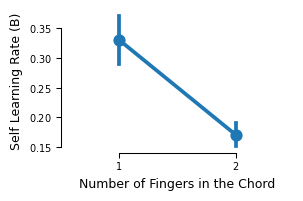

In [126]:
sns.pointplot(data = grouped_betas, x = 'num_fingers', y = 'mean_B_diag', errorbar='se')
plt.xlabel('Number of Fingers in the Chord')
plt.ylabel('Self Learning Rate (B)')
sns.despine(trim = True)

In [132]:
def determine_two_finger_chord_type(row):
    if row['num_fingers'] == 1:
        return 'one_finger'
    else:   
        fingers = row['chord'].split('-')
        if fingers[1] == fingers[2]:
            return 'symmetric'
        else:
            return 'asymmetric'

Text(0, 0.5, 'Cross-Finger LR (B)')

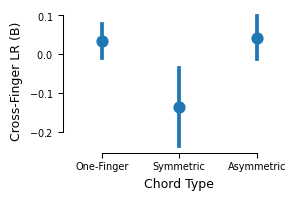

In [138]:
betas['chord_type'] = betas.apply(determine_two_finger_chord_type, axis = 1)
betas_grouped = betas.groupby(['chord_type', 'subNum']).agg({
    'mean_B_diag': 'mean',
    'mean_B_off_diag': 'mean',
}).reset_index()
chord_order = ['one_finger', 'symmetric', 'asymmetric']
betas_grouped['chord_type'] = pd.Categorical(
    betas_grouped['chord_type'],
    categories=chord_order,
    ordered=True,
)


sns.pointplot(data = betas_grouped, x = 'chord_type', y = 'mean_B_off_diag', errorbar='se',
linestyle = ' ')
sns.despine(trim = True)
plt.xlabel('Chord Type')
plt.xticks([0,1,2], ['One-Finger', 'Symmetric', 'Asymmetric'])
plt.ylabel('Cross-Finger LR (B)')

7.890674904191908
3.6638728308948076
8.097448124221199
11.091055547056746
10.069905590140618
12.543237910594566
10.852842219767766
11.798234008328112


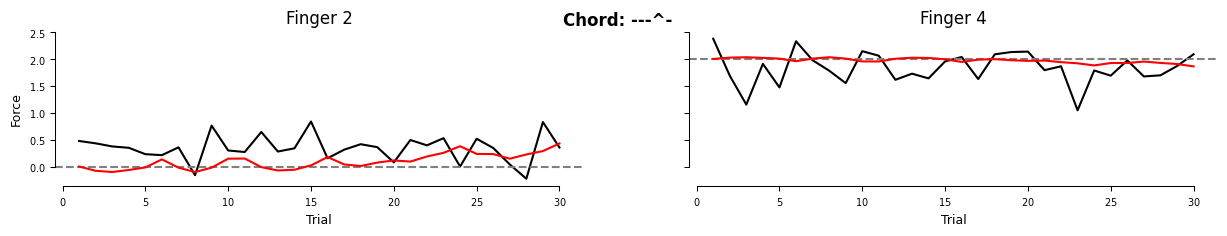

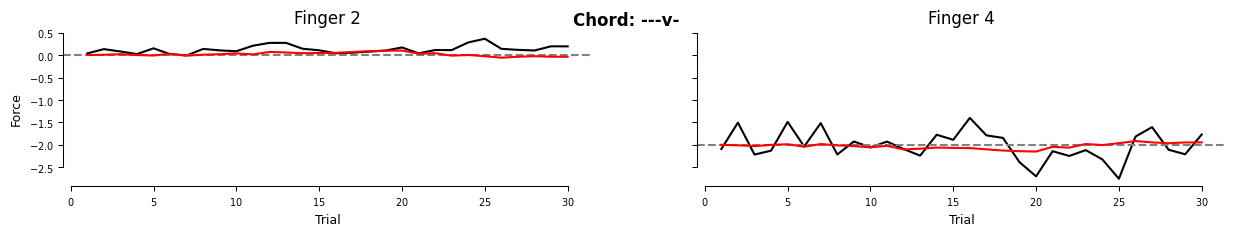

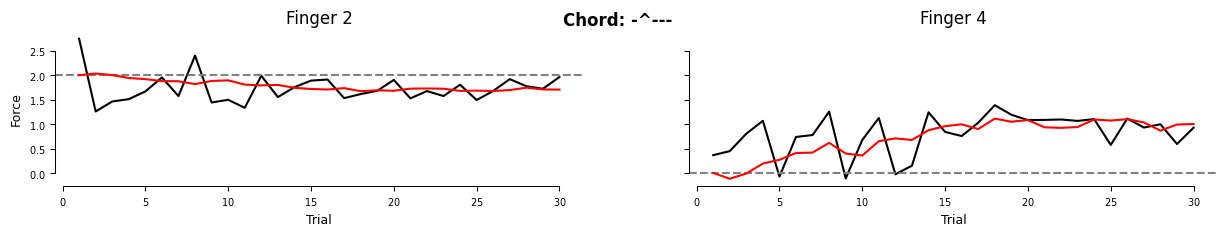

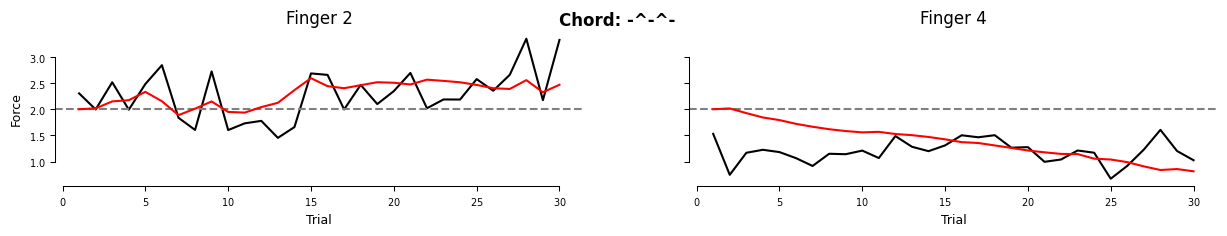

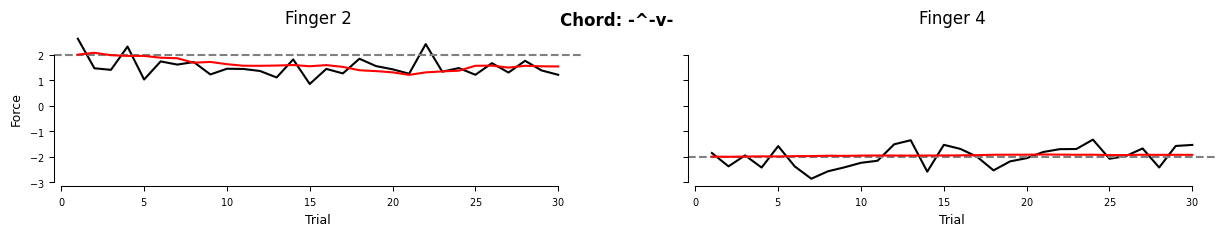

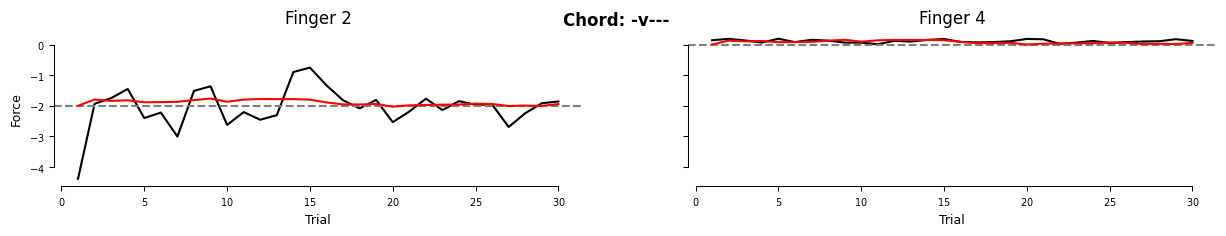

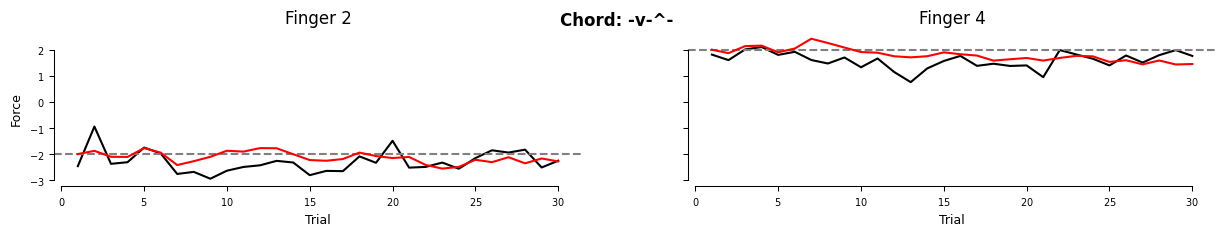

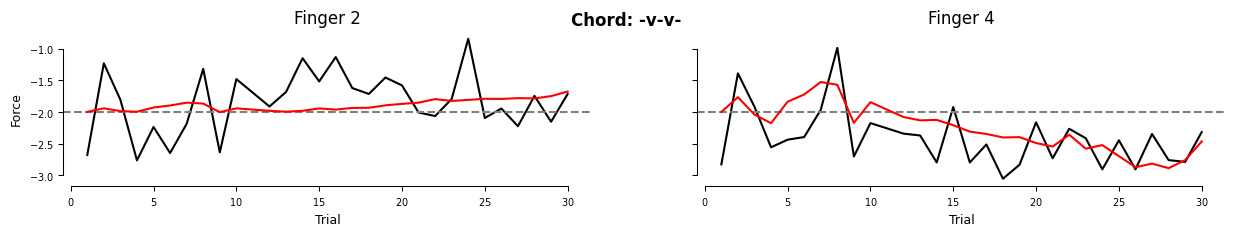

In [97]:
# assuming the following model:

# assumed here the target force is 0 (target is subtracted from following Xs and Zs)
# X_t = Z_t + \epsilon_t + p_t (the perturbation)
# where Z_t is the planned force, \epsilon_t is the execution noise, and p_t is the perturbation applied on trial t
# Z_t+1 = A * (Z_t) + B * (X_t)

# ==> X_t+1 - X_t = Z_t+1 - Z_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t
# ==> X_t+1 - X_t = A * Z_t + B * X_t - Z_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t
# ==> X_t+1 - X_t = (A - 1) * Z_t + B * X_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t
# ==> X_t+1 - X_t = (A - 1) * Z_t + B * (Z_t + \epsilon_t + p_t) + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t
# ==> X_t+1 - X_t = (A - 1) * Z_t + B * Z_t + B * \epsilon_t + B * p_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t
# ==> X_t+1 - X_t = (A - 1) * Z_t + (B - 1) * \epsilon_t + (B - 1) * p_t + \epsilon_t+1 - \epsilon_t + p_t+1 - p_t

# for each participant, we can do Expectation-Maximization to estimate parameters, A, B, and epsilon
# first we can fit to unpurturbed data (p_t = 0) to estimate A, B, and epsilon
# then we can use the estimated parameters to fit to purturbed data where p_t is not zero


from scipy.optimize import minimize

# --- 1. Define Model Functions ---

def unpack_params(params):
    """
    Unpacks the 8-parameter array.
    A is explicitly built as a diagonal matrix.
    """
    # Force A to be a diagonal matrix using the first two parameters
    A = np.array([[params[0], 0.0],
                  [0.0, params[1]]])
    
    # B remains a full 2x2 matrix
    B = params[2:6].reshape((2, 2))
    
    # Z0 is the initial state
    # Z0 = params[6:8]
    
    # return A, B, Z0
    return A, B

def get_residuals(params, X, P, mask):
    r"""Simulates the state forward and returns the execution noise (\epsilon_t)."""
    # A, B, Z0 = unpack_params(params)
    A, B = unpack_params(params)
    
    B_masked = B * mask
    
    num_trials = X.shape[0]
    Z = np.zeros((num_trials, 2))
    # Z[0] = Z0
    
    for t in range(num_trials - 1):
         Z[t+1] = A @ Z[t] - B_masked @ X[t]
         # Optional safety clip to absolutely prevent infinity if data is extremely noisy
         Z[t+1] = np.clip(Z[t+1], -10, 10) 
            
    eps = X - Z - P
    return eps

def objective(params, X, P, mask):
    r"""Minimizes the sum of squared execution noise (Equivalent to MLE)."""
    eps = get_residuals(params, X, P, mask)
    return np.sum(eps**2)

# --- 2. Process the Data ---

betas = []

# Define bounds for the 8 parameters
# A matrix (retention): only the diagonals, bounded strictly between 0 and 1
bounds_A = [(0.99, 1.0), (0.99, 1.0)]
# B matrix (learning rates): generously bounded between -1 and +1
bounds_B = [(-1, 1), (-1, 1), (-1, 1), (-1, 1)]
# Z0 (initial state): unconstrained
# bounds_Z0 = [(None, None), (None, None)]

# all_bounds = bounds_A + bounds_B + bounds_Z0
all_bounds = bounds_A + bounds_B

for chord, chord_data in subjs_correct.groupby('chord'):
    
    mask = np.ones((2, 2))
    for idx, finger in enumerate([2, 4]):
        if chord_data[f'targetForce{finger}'].iloc[0] == 0:
            mask[:, idx] = 0
            

    
    # Initial parameters (Length 8)
    # A_diag = [1.0, 1.0], B_flat = [0,0,0,0], Z0 = [0,0]
    # initial_params = np.concatenate([[1.0, 1.0], np.zeros(4), np.zeros(2)])
    initial_params = np.concatenate([[1.0, 1.0], np.zeros(4)])
    initial_params = np.concatenate([[1.0, 1.0], np.ones(4)])
    initial_params = np.concatenate([[1.0, 1.0], np.ones(4) / 2])



    grouped_data = chord_data.copy()
    grouped_data = grouped_data.groupby(['TN', 'block_type',
    'num_targets', 'chord']).agg({
        'endForcePurturbed2': 'mean',
        'endForcePurturbed4': 'mean',
        'endForce2': 'mean',
        'endForce4': 'mean',
        'purturbation1': 'mean',
        'purturbation2': 'mean',
        'targetForce2': 'mean',
        'targetForce4': 'mean',
    })
    grouped_data = grouped_data.reset_index()

    unpert_data = grouped_data[grouped_data['block_type'] == 'unpurturbed'].sort_values('TN')
    pert_data = grouped_data[grouped_data['block_type'] == 'purturbed'].sort_values('TN')

    # plot pert data 
    fig, axs = plt.subplots(1,2, figsize = (15,2), sharey = True)
    for idx, finger in enumerate([2,4]):
        sns.lineplot(data = pert_data, x = 'TN', y = f'endForce{finger}', ax = axs[idx],
        color = 'black')
        axs[idx].axhline(y = pert_data[f'targetForce{finger}'].iloc[0], color = 'gray', linestyle = '--')
        axs[idx].set_title(f'Finger {finger}')
        axs[idx].set_xlabel('Trial')
        axs[idx].set_ylabel('Force')
        axs[idx].set_title(f'Finger {finger}')



    # --- PHASE 1: Fit Unperturbed Data ---
    # if not unpert_data.empty:
    #     X_unpert = unpert_data[[f'endForcePurturbed{i}' for i in [2, 4]]].values
    #     target_force = unpert_data[[f'targetForce{i}' for i in [2, 4]]].values
    #     # subtract the target force from the endForcePurturbed
    #     X_unpert = X_unpert - target_force

    #     P_unpert = np.zeros_like(X_unpert)
        
    #     # Seed the initial state guess with the first observed force
    #     initial_params[-2:] = X_unpert[0] 
        
    #     # print("Fitting unperturbed data")

    #     res_unpert = minimize(
    #         objective, 
    #         initial_params, 
    #         args=(X_unpert, P_unpert, mask), 
    #         # method='L-BFGS-B',
    #         method = 'Nelder-Mead',
    #         bounds=all_bounds
    #     )
    #     phase1_params = res_unpert.x
    # else:
    #     phase1_params = initial_params 
        
    # --- PHASE 2: Fit Perturbed Data ---
    if not pert_data.empty:
        X_pert = pert_data[[f'endForcePurturbed{i}' for i in [2, 4]]].values
        target_force = pert_data[[f'targetForce{i}' for i in [2, 4]]].values
        X_pert = X_pert - target_force
        P_pert = pert_data[[f'purturbation{i}' for i in [1, 2]]].values
        

        # print("Fitting perturbed data")

        # res_pert = minimize(
        #     objective, 
        #     phase1_params, 
        #     args=(X_pert, P_pert, mask), 
        #     # method='L-BFGS-B',
        #     method = 'Nelder-Mead',
        #     bounds=all_bounds
        # )

        res_pert = minimize(
            objective, 
            initial_params, 
            args=(X_pert, P_pert, mask), 
            # method='L-BFGS-B',
            method = 'Nelder-Mead',
            bounds=all_bounds
        )
        
        # A_final, B_final, Z0_final = unpack_params(res_pert.x)
        A_final, B_final = unpack_params(res_pert.x)

        B_masked = B_final * mask

        
        # B_final = np.where(mask == 1, B_final, np.nan)

        # generate the predicted force
        Z_pert = pd.DataFrame(columns = ['TN', 'endForce2', 'endForce4'])
        pert_data.reset_index(drop = True, inplace = True)
        Z_pert['TN'] = pert_data['TN']
        # Z_pert['endForce2'] = Z0_final[0]
        # Z_pert['endForce4'] = Z0_final[1]
        Z_pert['endForce2'] = 0.0
        Z_pert['endForce4'] = 0.0


        for t in range(X_pert.shape[0] - 1):
            Z_pert.loc[t+1, 'endForce2'] = A_final[0, 0] * Z_pert.loc[t, 'endForce2'] - B_masked[0, 0] * X_pert[t, 0] - B_masked[0, 1] * X_pert[t, 1]
            Z_pert.loc[t+1, 'endForce4'] = A_final[1, 1] * Z_pert.loc[t, 'endForce4'] - B_masked[1, 0] * X_pert[t, 0] - B_masked[1, 1] * X_pert[t, 1]

        # for t in range(X_pert.shape[0] - 1):
        #     if pert_data['targetForce2'].iloc[t] == 0:
        #         Z_pert.loc[t+1, 'endForce2'] = A_final[0, 0] * Z_pert.loc[t, 'endForce2'] - B_final[0, 1] * X_pert[t, 1]
        #         Z_pert.loc[t+1, 'endForce4'] = A_final[1, 1] * Z_pert.loc[t, 'endForce4'] - B_final[1, 1] * X_pert[t, 1]

        #     elif pert_data['targetForce4'].iloc[t] == 0:
        #         Z_pert.loc[t+1, 'endForce2'] = A_final[0, 0] * Z_pert.loc[t, 'endForce2'] - B_final[0, 0] * X_pert[t, 0]
        #         Z_pert.loc[t+1, 'endForce4'] = A_final[1, 1] * Z_pert.loc[t, 'endForce4'] - B_final[1, 0] * X_pert[t, 0]

        #     else:
        #         Z_pert.loc[t+1, 'endForce2'] = A_final[0, 0] * Z_pert.loc[t, 'endForce2'] + B_final[0, 0] * X_pert[t, 0] + B_final[0, 1] * X_pert[t, 1]
        #         Z_pert.loc[t+1, 'endForce4'] = A_final[1, 1] * Z_pert.loc[t, 'endForce4'] + B_final[1, 0] * X_pert[t, 0] + B_final[1, 1] * X_pert[t, 1]


        for t in range(X_pert.shape[0]):
            Z_pert.loc[t, 'endForce2'] += pert_data['targetForce2'].iloc[0]
            Z_pert.loc[t, 'endForce4'] += pert_data['targetForce4'].iloc[0]
        # plot the predicted force
        for idx, finger in enumerate([2,4]):
            sns.lineplot(data = Z_pert, x = 'TN', y = f'endForce{finger}', ax = axs[idx],
            color = 'red')

            axs[idx].set_title(f'Finger {finger}')
            axs[idx].set_xlabel('Trial')
            axs[idx].set_ylabel('Force')

        fig.suptitle(f'Chord: {chord}')
        sns.despine(trim = True)
    

        B_final = np.where(mask == 1, B_final, np.nan)


        eps_final = get_residuals(res_pert.x, X_pert, P_pert, mask)
        print(np.sum(eps_final**2))
        cov_eps = np.cov(eps_final.T)
        
        betas.append({
            'chord': chord,
            'num_fingers': pert_data['num_targets'].iloc[0],
            'A11': np.round(A_final[0, 0], 3),
            'A12': 0.0, # Explicitly zero now
            'A21': 0.0, # Explicitly zero now
            'A22': np.round(A_final[1, 1], 3),
            'B11': np.round(B_final[0, 0], 3),
            'B12': np.round(B_final[0, 1], 3),
            'B21': np.round(B_final[1, 0], 3),
            'B22': np.round(B_final[1, 1], 3),
            'eps_var1': np.round(cov_eps[0, 0], 3),
            'eps_var2': np.round(cov_eps[1, 1], 3)
        })

betas_df = pd.DataFrame(betas)

In [98]:
betas_df

,chord,num_fingers,A11,A12,A21,A22,B11,B12,B21,B22,eps_var1,eps_var2
0,---^-,1,0.995,0.0,0.0,1.00,NaN,0.187,NaN,-0.059,0.089,0.097
1,---v-,1,1.000,0.0,0.0,1.00,NaN,-0.045,NaN,0.065,0.010,0.104
2,-^---,1,0.990,0.0,0.0,0.99,-0.067,NaN,0.228,NaN,0.107,0.160
3,-^-^-,2,1.000,0.0,0.0,0.99,0.214,0.046,-0.013,-0.058,0.168,0.173
4,-^-v-,2,0.999,0.0,0.0,0.99,-0.034,-0.115,0.007,0.009,0.171,0.166
5,-v---,1,0.990,0.0,0.0,1.00,0.088,NaN,0.055,NaN,0.403,0.005
6,-v-^-,2,0.990,0.0,0.0,0.99,0.230,-0.203,-0.202,0.085,0.177,0.123
7,-v-v-,2,1.000,0.0,0.0,0.99,0.037,0.054,0.331,0.209,0.243,0.152


In [99]:
betas_df['mean_B_diag'] = betas_df[['B11', 'B22']].mean(axis = 1)
betas_df['mean_B_off_diag'] = betas_df[['B12', 'B21']].mean(axis = 1)

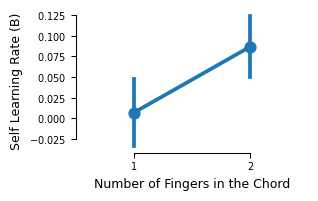

In [100]:
sns.pointplot(data = betas_df, x = 'num_fingers', y = 'mean_B_diag', errorbar='se')
plt.xlabel('Number of Fingers in the Chord')
plt.ylabel('Self Learning Rate (B)')
sns.despine(trim = True)

In [101]:
def determine_two_finger_chord_type(row):
    if row['num_fingers'] == 1:
        return 'one_finger'
    else:   
        fingers = row['chord'].split('-')
        if fingers[1] == fingers[2]:
            return 'symmetric'
        else:
            return 'asymmetric'


In [102]:
betas_df['chord_type'] = betas_df.apply(determine_two_finger_chord_type, axis = 1)
betas_df

,chord,num_fingers,A11,A12,A21,A22,B11,B12,B21,B22,eps_var1,eps_var2,mean_B_diag,mean_B_off_diag,chord_type
0,---^-,1,0.995,0.0,0.0,1.00,NaN,0.187,NaN,-0.059,0.089,0.097,-0.0590,0.1870,one_finger
1,---v-,1,1.000,0.0,0.0,1.00,NaN,-0.045,NaN,0.065,0.010,0.104,0.0650,-0.0450,one_finger
2,-^---,1,0.990,0.0,0.0,0.99,-0.067,NaN,0.228,NaN,0.107,0.160,-0.0670,0.2280,one_finger
3,-^-^-,2,1.000,0.0,0.0,0.99,0.214,0.046,-0.013,-0.058,0.168,0.173,0.0780,0.0165,symmetric
4,-^-v-,2,0.999,0.0,0.0,0.99,-0.034,-0.115,0.007,0.009,0.171,0.166,-0.0125,-0.0540,asymmetric
5,-v---,1,0.990,0.0,0.0,1.00,0.088,NaN,0.055,NaN,0.403,0.005,0.0880,0.0550,one_finger
6,-v-^-,2,0.990,0.0,0.0,0.99,0.230,-0.203,-0.202,0.085,0.177,0.123,0.1575,-0.2025,asymmetric
7,-v-v-,2,1.000,0.0,0.0,0.99,0.037,0.054,0.331,0.209,0.243,0.152,0.1230,0.1925,symmetric


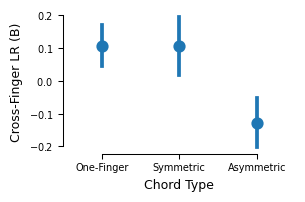

In [103]:
sns.pointplot(data = betas_df, x = 'chord_type', y = 'mean_B_off_diag', errorbar='se', linestyle = ' ')
plt.xlabel('Chord Type')
plt.ylabel('Cross-Finger LR (B)')
plt.xticks([0, 1, 2], ['One-Finger', 'Symmetric', 'Asymmetric'])
sns.despine(trim = True)
